In [ ]:
'''How does the time of day influence the cooling effect of rain, and how long does this effect last?
'''

C:\Users\polis\AppData\Local\Temp\ipykernel_24148\2035089452.py:32: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['event_start'] = (df['rain_flag'] & ~df['rain_flag'].shift(1).fillna(False))


Average Cooling Effect and Recovery Time by Time of Day:
                     cooling_effect_C  recovery_time_hours
time_of_day                                               
Morning                      0.870250             3.234043
Afternoon                    2.031915             2.300000
Night/Early Morning          0.964593             2.490196


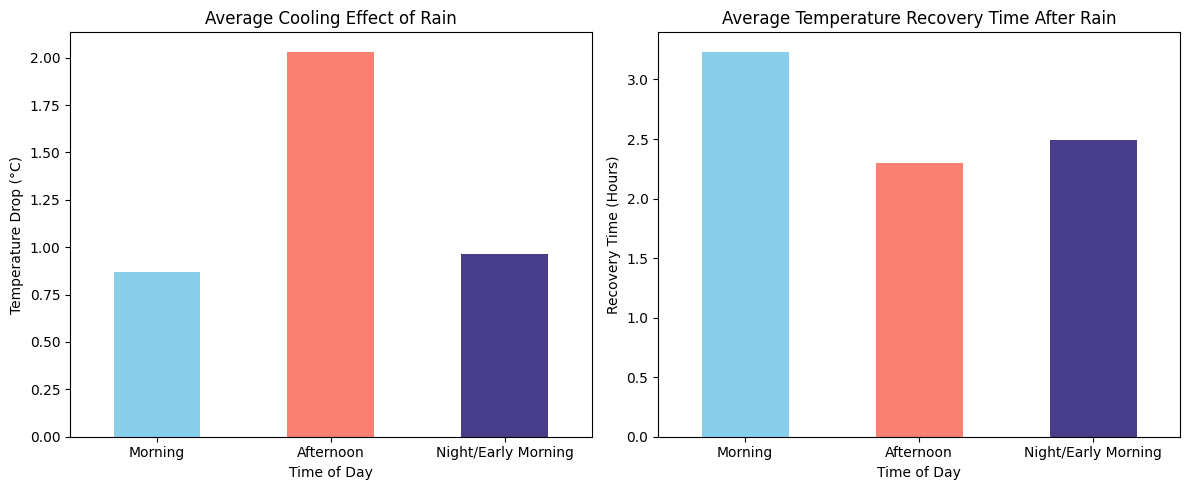


Detailed metrics for each rain event have been saved to 'rain_event_metrics.csv'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
# Correcting the file path based on the notebook's code.
file_path = 'datasets/Revised_Final_Data/Station1_Revised_Final_Data.csv'


df = pd.read_csv(file_path, parse_dates=['Date'], index_col='Date')


# Create rain flag and hour columns
df['rain_flag'] = df['Ppt'] > 0
df['hour'] = df.index.hour

# Identify the start of each rain event
df['event_start'] = (df['rain_flag'] & ~df['rain_flag'].shift(1).fillna(False))

# Assign a unique ID to each rain event
df['event_id'] = df['event_start'].cumsum()
df['event_id'] = df.apply(lambda row: row['event_id'] if row['rain_flag'] else 0, axis=1)

# Filter for only the rainy periods
rain_events_df = df[df['rain_flag']].copy()


event_metrics = []

# Ensure there are rain events to process
if not rain_events_df.empty:
    for event_id in rain_events_df['event_id'].unique():
        if event_id == 0:
            continue

        event_data = rain_events_df[rain_events_df['event_id'] == event_id]
        
        # Event start and end times
        start_time = event_data.index.min()
        end_time = event_data.index.max()
        duration = (end_time - start_time).total_seconds() / 3600 + 1
        
        # Categorize by time of day
        start_hour = start_time.hour
        if 6 <= start_hour < 12:
            time_of_day = 'Morning'
        elif 12 <= start_hour < 18:
            time_of_day = 'Afternoon'
        else:
            time_of_day = 'Night/Early Morning'
            
        # Calculate cooling effect
        temp_at_start = df.loc[start_time, 'Tair']
        min_temp_during_event = event_data['Tair'].min()
        cooling_effect = temp_at_start - min_temp_during_event
        
        # Get the temperature profile for 6 hours after the rain stops
        recovery_period_start = end_time + pd.Timedelta(hours=1)
        recovery_period_end = end_time + pd.Timedelta(hours=6)
        recovery_data = df.loc[recovery_period_start:recovery_period_end, 'Tair']
        
        # Get the expected temperature from the diurnal cycle of dry days
        dry_day_diurnal_temp = df[~df['rain_flag']].groupby('hour')['Tair'].mean()
        
        recovery_time = np.nan
        if not recovery_data.empty:
            # Compare actual temp to expected dry temp
            for i, (timestamp, temp) in enumerate(recovery_data.items()):
                expected_temp = dry_day_diurnal_temp.loc[timestamp.hour]
                if abs(temp - expected_temp) <= 1.0:
                    recovery_time = i + 1  # in hours
                    break
        
        event_metrics.append({
            'event_id': event_id,
            'time_of_day': time_of_day,
            'duration_hours': duration,
            'cooling_effect_C': cooling_effect,
            'recovery_time_hours': recovery_time
        })

if event_metrics:
    # Create a DataFrame from the metrics
    metrics_df = pd.DataFrame(event_metrics)

    # Group by time of day and calculate averages
    summary = metrics_df.groupby('time_of_day').agg({
        'cooling_effect_C': 'mean',
        'recovery_time_hours': 'mean'
    }).reindex(['Morning', 'Afternoon', 'Night/Early Morning'])

    print("Average Cooling Effect and Recovery Time by Time of Day:")
    print(summary)

    # Plotting the results
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

    # Bar chart for Cooling Effect
    summary['cooling_effect_C'].plot(kind='bar', ax=axes[0], color=['skyblue', 'salmon', 'darkslateblue'])
    axes[0].set_title('Average Cooling Effect of Rain')
    axes[0].set_ylabel('Temperature Drop (°C)')
    axes[0].set_xlabel('Time of Day')
    axes[0].tick_params(axis='x', rotation=0)

    # Bar chart for Recovery Time
    summary['recovery_time_hours'].plot(kind='bar', ax=axes[1], color=['skyblue', 'salmon', 'darkslateblue'])
    axes[1].set_title('Average Temperature Recovery Time After Rain')
    axes[1].set_ylabel('Recovery Time (Hours)')
    axes[1].set_xlabel('Time of Day')
    axes[1].tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.savefig("rain_effect_analysis.png")
    plt.show()

    # Save the detailed metrics to a CSV file for further inspection
    metrics_df.to_csv("rain_event_metrics.csv", index=False)
else:
    print("No rain events were found in the dataset to analyze.")